# Weekend 1 — The Ghost in the Machine: EDA & Stationarity

**Series:** From Random Walks to Neural Nets: A Time Series Journey Through 8 Years of German Weather  
**Dataset:** Jena Climate 2009–2016 (Max Planck Institute for Biogeochemistry)  
**Target variable:** `T (degC)` — air temperature at 2 m height

This notebook covers:
1. Loading and preprocessing the raw 10-minute data to hourly
2. Visual EDA — raw series, rolling statistics, distribution
3. Classical decomposition (yearly and daily periods)
4. Stationarity testing: ADF + KPSS
5. Setting up the train/val/test split for the rest of the series

**Runtime:** ~60 s on a modern laptop (the yearly decomposition is the slow step — ~30 s).

## 0. Setup

In [ ]:
# Add the repo root to sys.path so `src/` imports resolve regardless of
# where Jupyter is launched from.
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# Shared style + loader used by every weekend in the series
from src.data_loader import load_hourly, get_splits, TARGET
from src.plotting import apply_style, save_plot, BLUE, GRAY, ORANGE, RED

# Apply the series-wide matplotlib style (fonts, grid, DPI, etc.)
apply_style()

# Render plots inline in the notebook
%matplotlib inline

# ---------------------------------------------------------------------------
# Constants — define once here, never scatter magic numbers through cells
# ---------------------------------------------------------------------------

# Where the five required PNGs get saved
IMAGES_DIR = ROOT / "posts" / "images" / "weekend_1"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# 30-day window for rolling statistics (captures seasonal shape without being noisy)
ROLLING_WINDOW_DAYS = 30
ROLLING_WINDOW_H    = ROLLING_WINDOW_DAYS * 24  # 720 hours

# Decomposition periods
YEARLY_PERIOD = 8766   # 365.25 days * 24 h — accounts for leap years
DAILY_PERIOD  = 24     # one full diurnal cycle

# A single representative month for the daily decomposition plot
SAMPLE_MONTH_START = "2014-07-01"
SAMPLE_MONTH_END   = "2014-07-31"

# Significance level used for both hypothesis tests
ALPHA = 0.05

## 1. Load & Inspect Data

In [14]:
# load_hourly() handles the full preprocessing pipeline:
#   raw 10-min CSV → parse DD.MM.YYYY timestamps → drop duplicates
#   → resample to hourly mean → forward-fill gaps ≤ 6 h → truncate 2009–2016
df = load_hourly()

print(f"Shape          : {df.shape}")
print(f"Index dtype    : {df.index.dtype}")
print(f"Date range     : {df.index.min()} → {df.index.max()}")
print(f"Inferred freq  : {df.index.freq}")
# Remaining NaNs are gaps longer than 6 hours — intentionally left as NaN
print(f"Missing T vals : {df[TARGET].isna().sum()} (gaps > 6 h, left as NaN)")
print()
df[TARGET].describe().round(2)

Shape          : (70128, 14)
Index dtype    : datetime64[ns]
Date range     : 2009-01-01 00:00:00 → 2016-12-31 23:00:00
Inferred freq  : <Hour>
Missing T vals : 76 (gaps > 6 h, left as NaN)



count    70052.00
mean         9.44
std          8.41
min        -22.65
25%          3.36
50%          9.41
75%         15.46
max         37.04
Name: T (degC), dtype: float64

In [15]:
# Confirm the locked train/val/test boundaries used by every weekend in the series.
# These dates never change — they are set in src/data_loader.py.
train, val, test = get_splits(df)

for name, split in [("Train", train), ("Val", val), ("Test", test)]:
    print(
        f"{name:6s}: {split.index.min().date()} → {split.index.max().date()}"
        f"  ({len(split):,} rows)"
    )

Train : 2009-01-01 → 2014-12-31  (52,584 rows)
Val   : 2015-01-01 → 2015-12-31  (8,760 rows)
Test  : 2016-01-01 → 2016-12-31  (8,784 rows)


## 2. Plot 1 — Raw Hourly Temperature Series

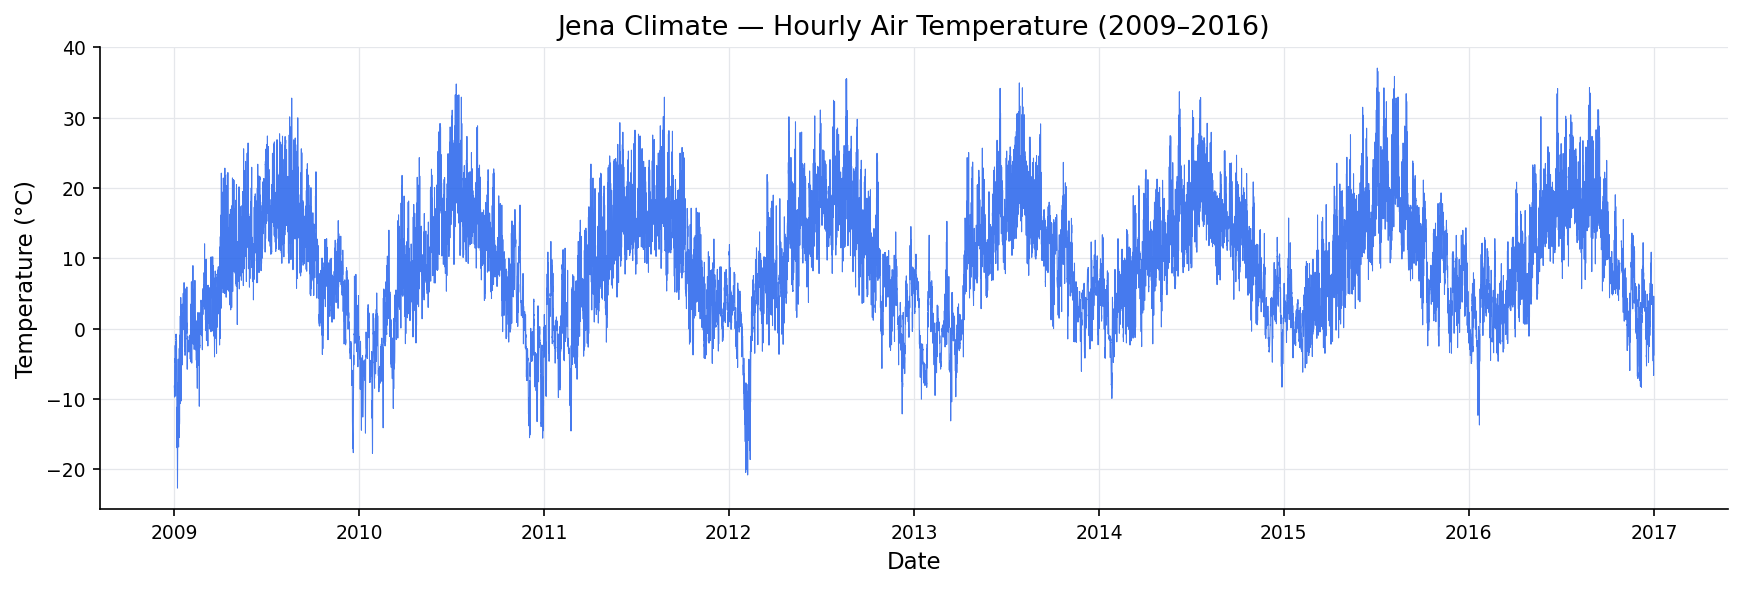

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))

# Thin line at 0.5 alpha so dense overlapping hours are still readable
ax.plot(df.index, df[TARGET], color=BLUE, linewidth=0.5, alpha=0.85)

ax.set_title("Jena Climate — Hourly Air Temperature (2009–2016)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")

# One tick per year keeps the x-axis readable at this width
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Save to disk (close=False keeps the figure alive for inline display below)
save_plot(fig, IMAGES_DIR / "raw_temperature.png", close=False)
plt.show()

## 3. Plot 2 — Rolling Statistics (Visual Stationarity Check)

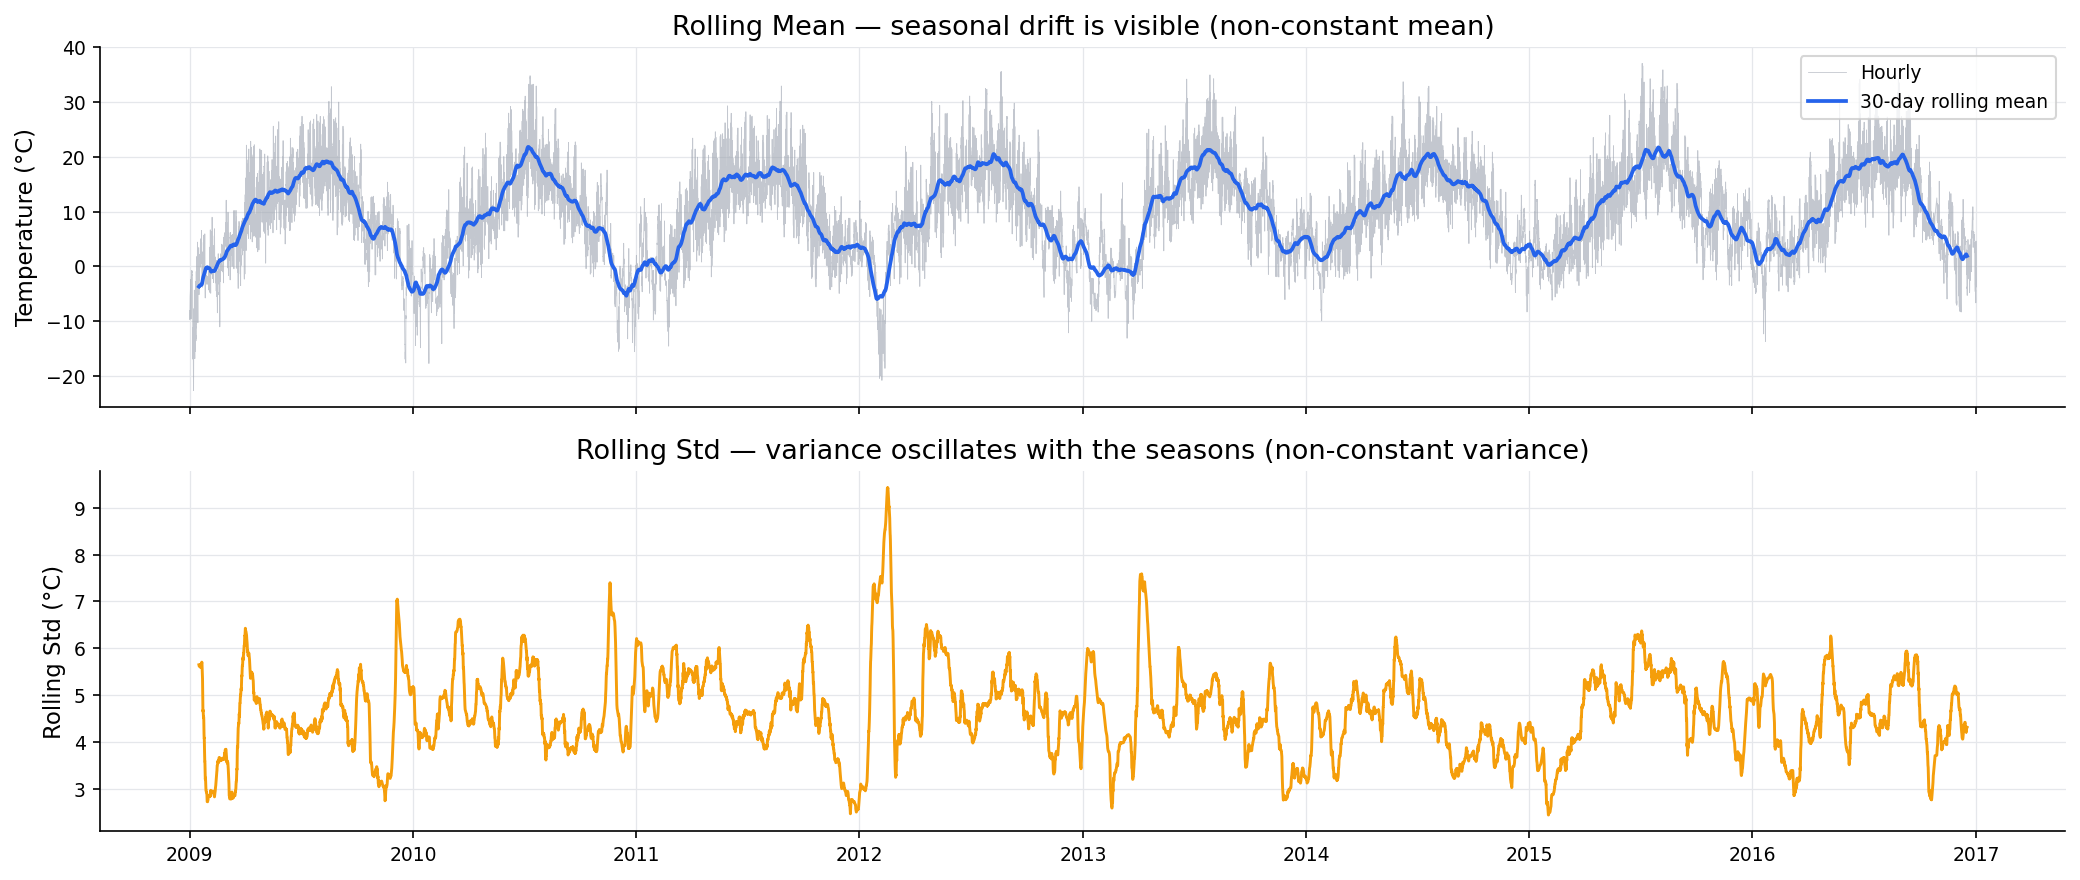

In [17]:
temp = df[TARGET].dropna()

# center=True aligns the rolling window symmetrically around each point,
# so the mean doesn't lag behind the data it summarises
roll_mean = temp.rolling(window=ROLLING_WINDOW_H, center=True).mean()
roll_std  = temp.rolling(window=ROLLING_WINDOW_H, center=True).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top panel: raw (faint) + rolling mean (bold)
# A stationary series would show a flat rolling mean; the sinusoidal drift
# here is the visual signature of non-stationarity.
ax1.plot(temp.index, temp.values,
         color=GRAY, linewidth=0.4, alpha=0.6, label="Hourly")
ax1.plot(roll_mean.index, roll_mean.values,
         color=BLUE, linewidth=1.8, label=f"{ROLLING_WINDOW_DAYS}-day rolling mean")
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Rolling Mean — seasonal drift is visible (non-constant mean)")
ax1.legend(loc="upper right", fontsize=9)

# Bottom panel: rolling std
# Stationarity also requires constant variance; the oscillating std confirms
# that variance itself is seasonal (higher in winter, lower in summer).
ax2.plot(roll_std.index, roll_std.values, color=ORANGE, linewidth=1.4)
ax2.set_ylabel("Rolling Std (°C)")
ax2.set_title("Rolling Std — variance oscillates with the seasons (non-constant variance)")
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
save_plot(fig, IMAGES_DIR / "rolling_stats.png", close=False)
plt.show()

## 4. Plot 3 — Classical Decomposition (Yearly Period)

> **Note:** This cell takes ~30 seconds — the yearly decomposition requires a moving average over 8,766 observations.

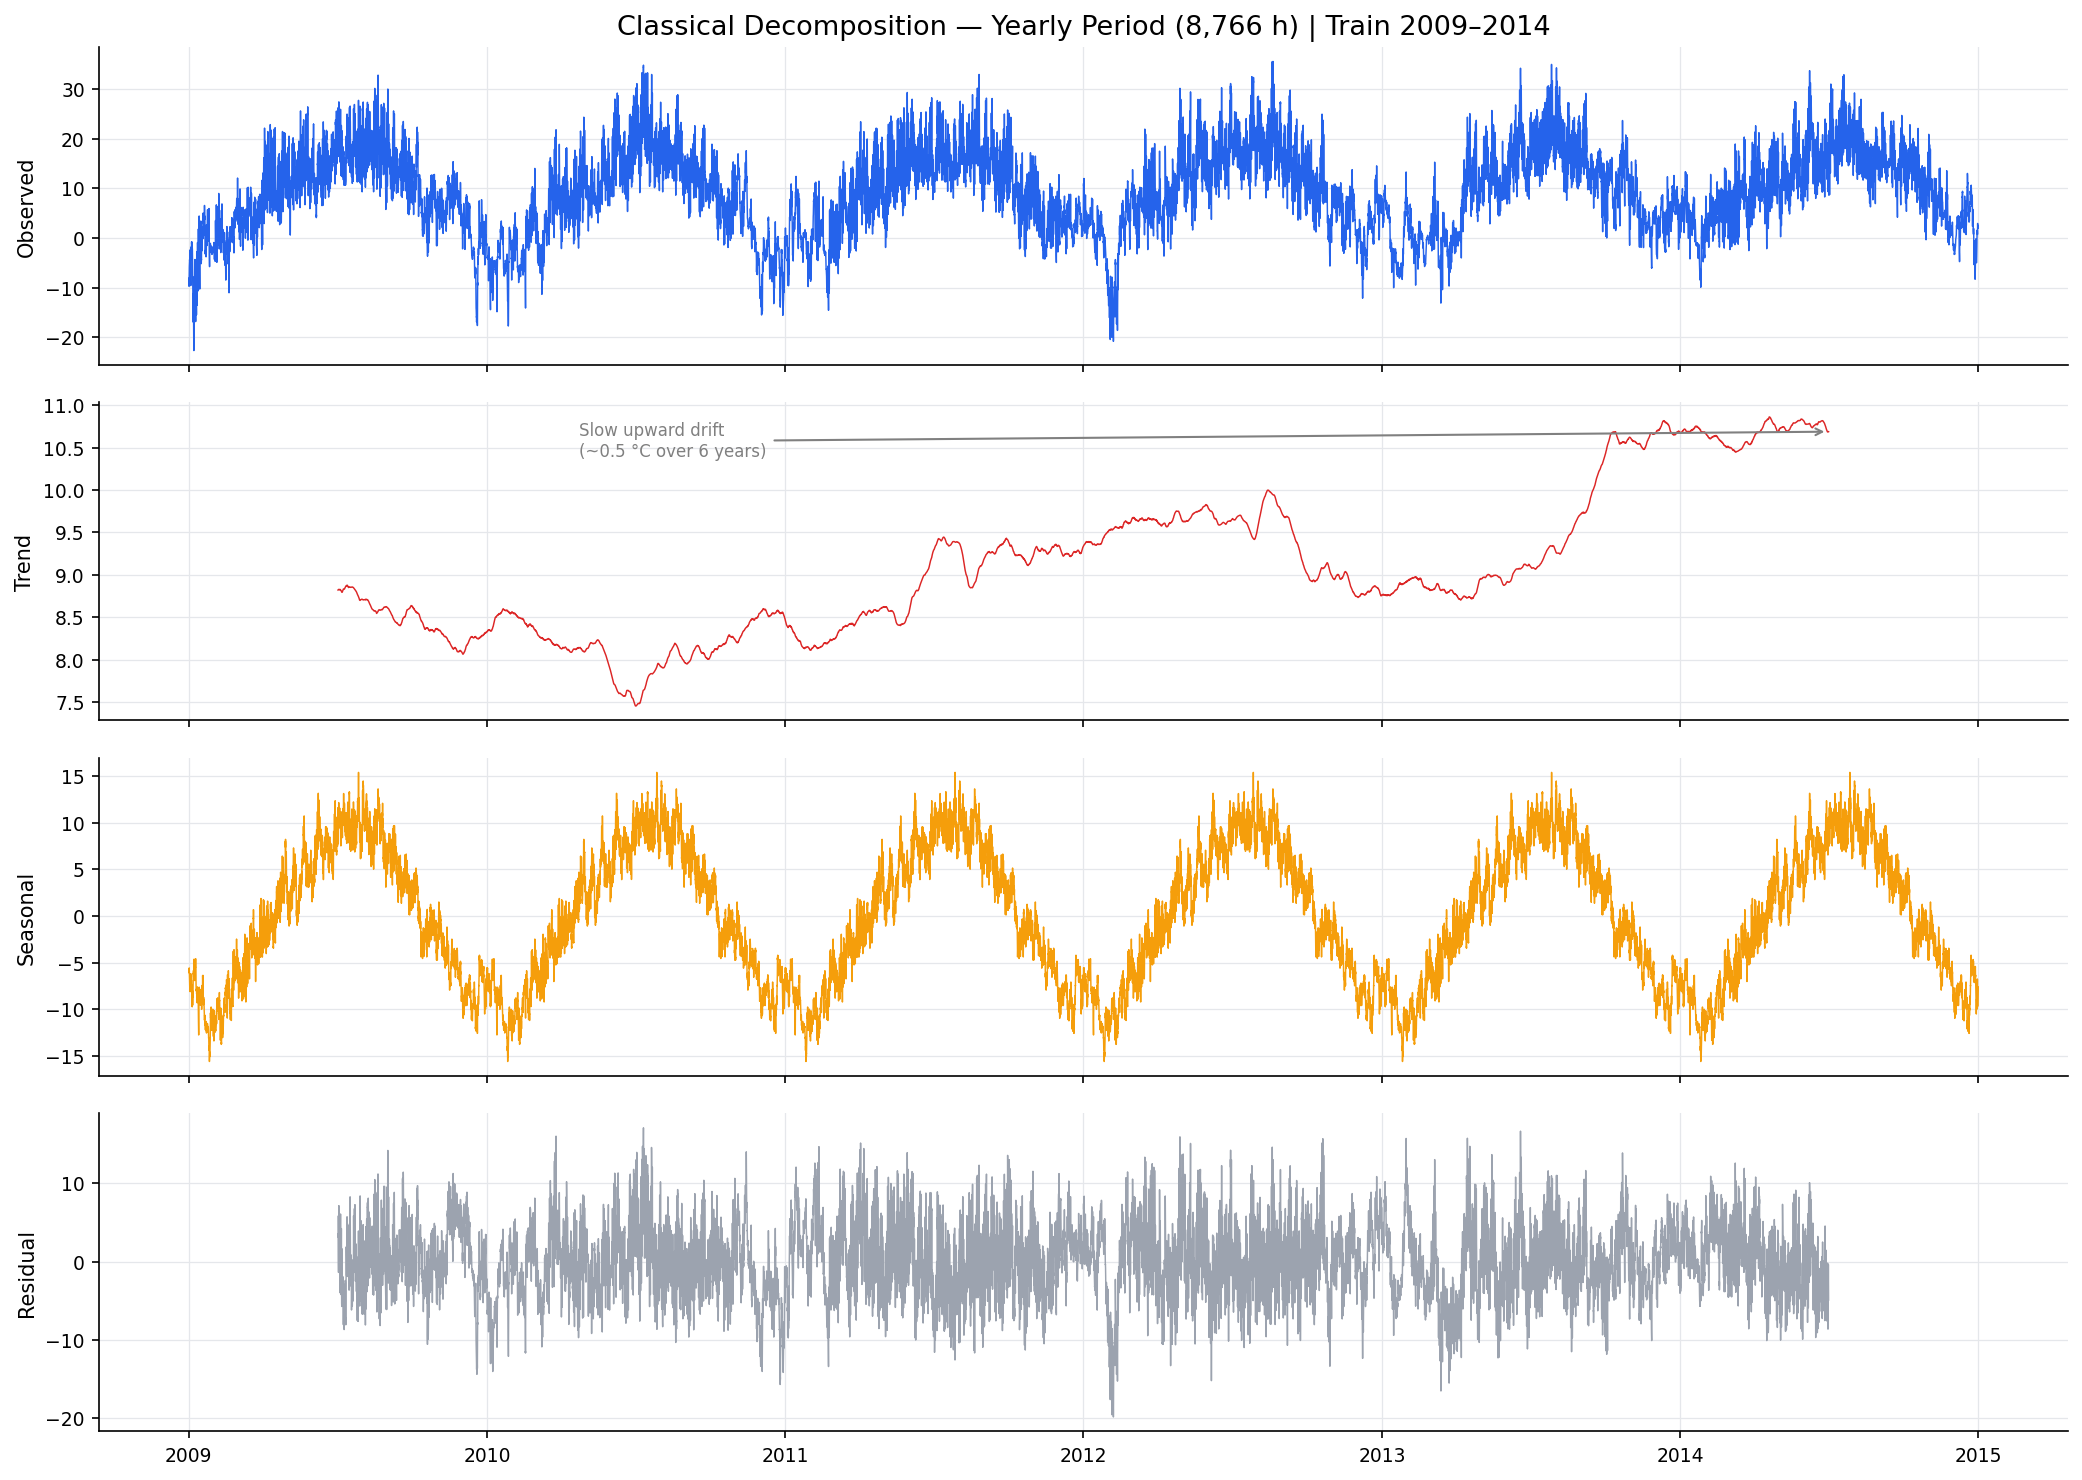

In [18]:
# Use training data only — never expose val/test signal during exploratory analysis
temp_train = train[TARGET].dropna()

# Additive model assumes: observed = trend + seasonal + residual
# This is appropriate here because the seasonal amplitude looks roughly
# constant over time (not growing with the series level).
# extrapolate_trend='freq' avoids NaN edges caused by the centred MA window.
decomp_yearly = seasonal_decompose(
    temp_train,
    model="additive",
    period=YEARLY_PERIOD
)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = [
    (decomp_yearly.observed,  "Observed",  BLUE),
    (decomp_yearly.trend,     "Trend",     RED),
    (decomp_yearly.seasonal,  "Seasonal",  ORANGE),
    (decomp_yearly.resid,     "Residual",  GRAY),
]

for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=0.7)
    ax.set_ylabel(label, fontsize=10)
    ax.spines["left"].set_visible(True)

# Annotate the warming signal in the trend panel
# The slow upward drift (~0.5 °C over 6 years) is real climate signal,
# not noise — this is what drives the mild non-stationarity in the long run.
trend_series = decomp_yearly.trend.dropna()
axes[1].annotate(
    "Slow upward drift\n(~0.5 °C over 6 years)",
    xy=(trend_series.index[-1], trend_series.iloc[-1]),
    xytext=(-600, -12),
    textcoords="offset points",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="gray"),
    color="gray",
)

axes[0].set_title("Classical Decomposition — Yearly Period (8,766 h) | Train 2009–2014")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
save_plot(fig, IMAGES_DIR / "decomposition_yearly.png", close=False)
plt.show()

## 5. Plot 4 — Classical Decomposition (Daily Period, Sampled Month)

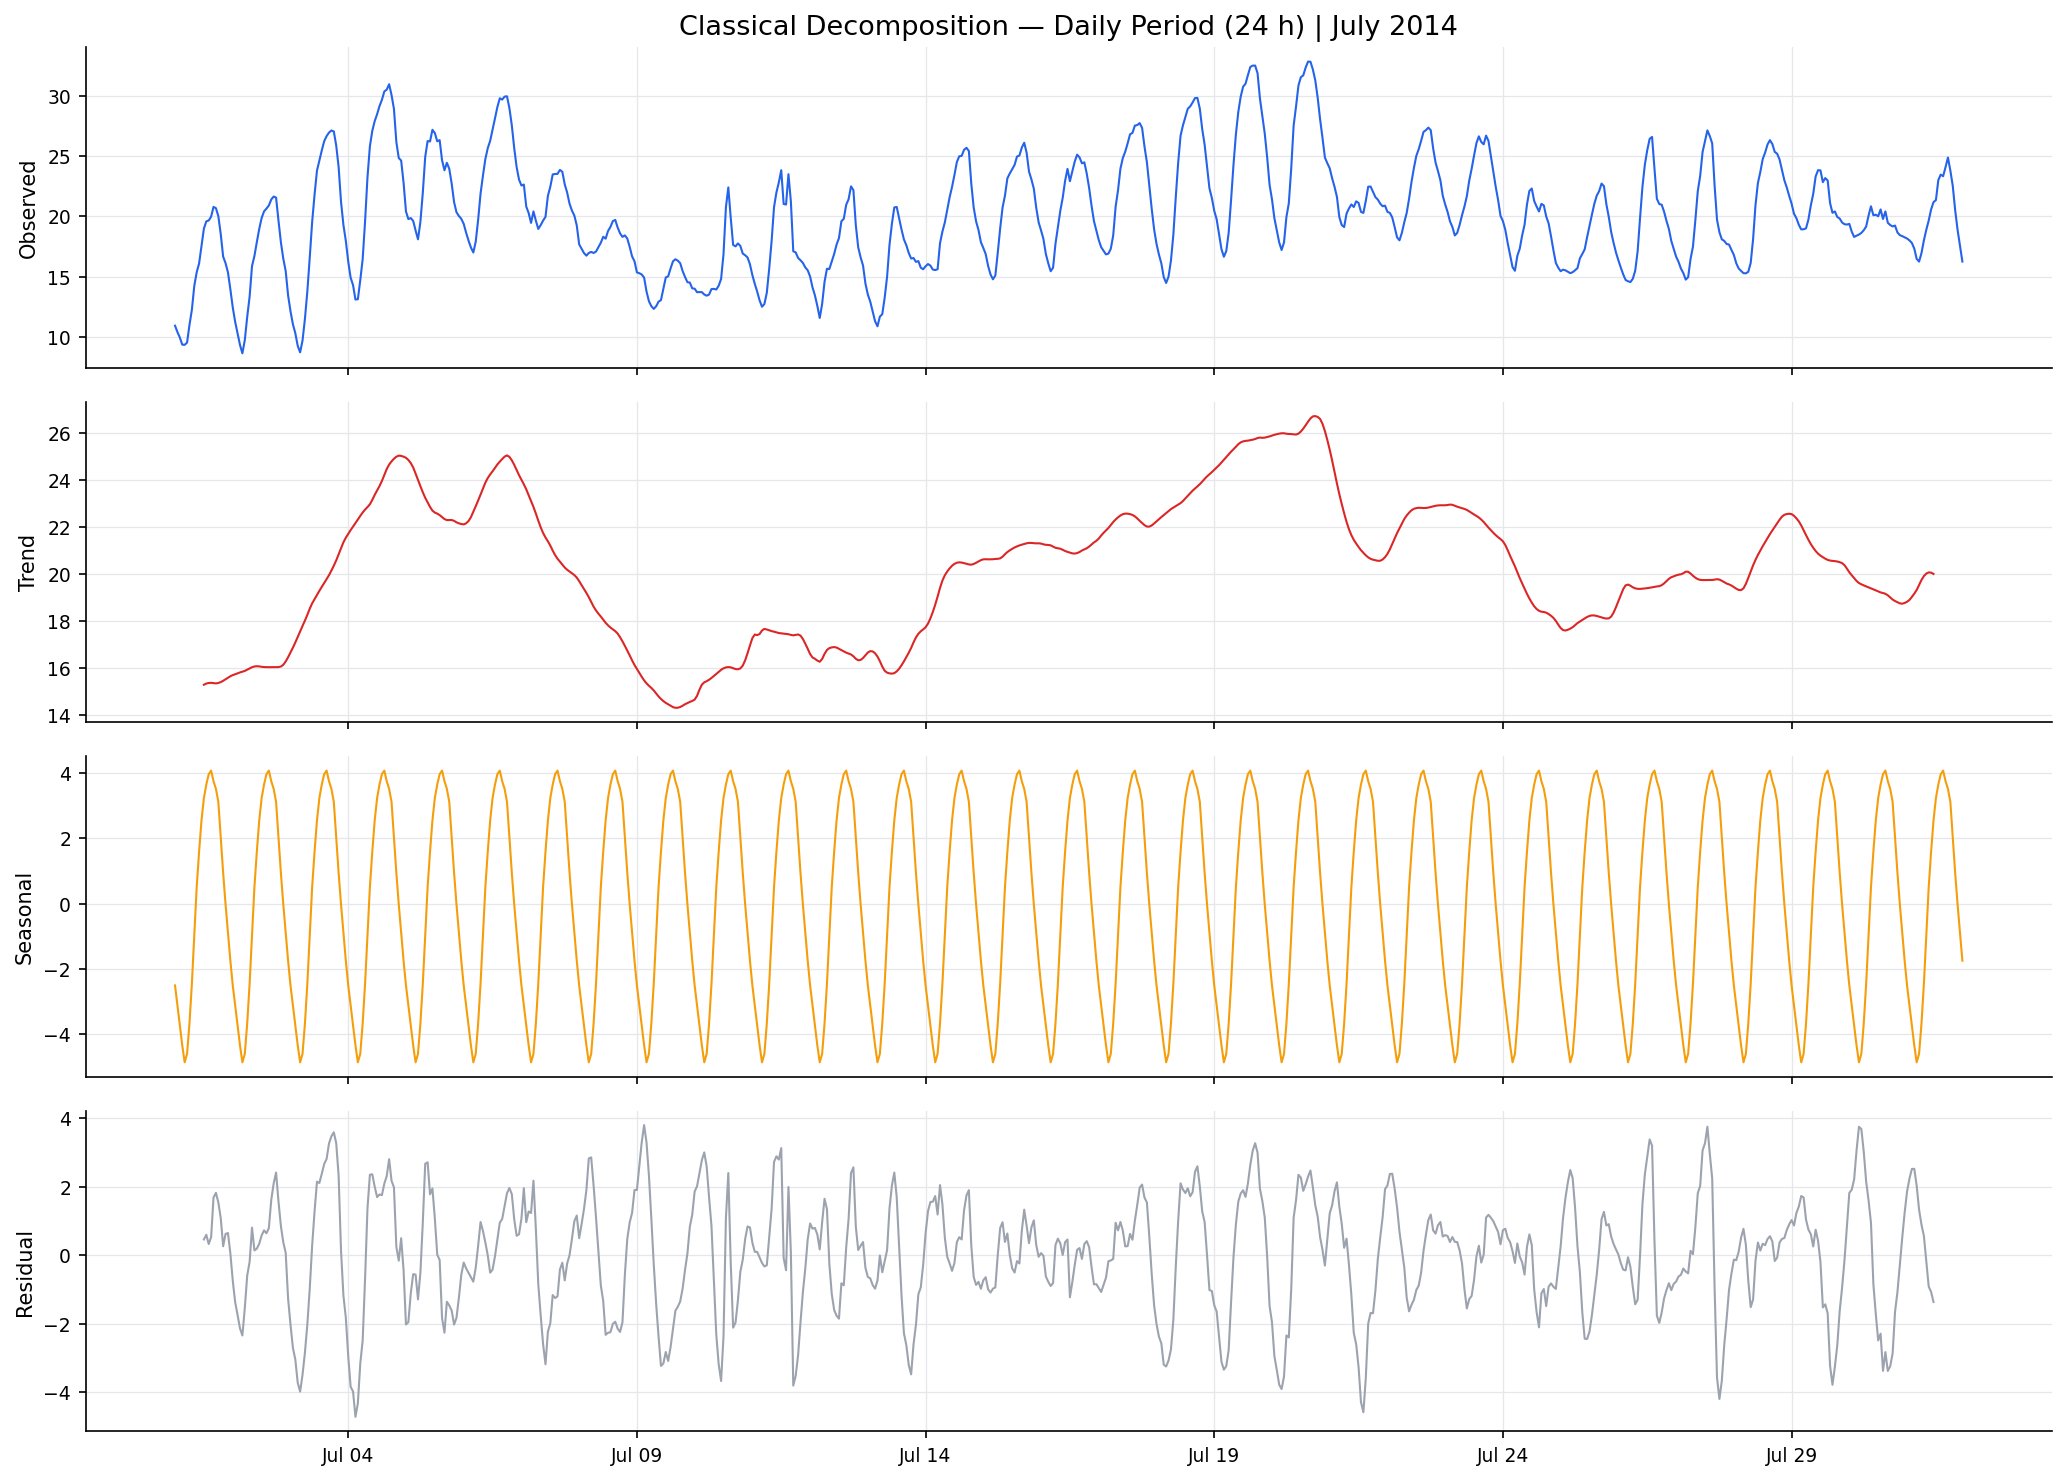

In [19]:
# July 2014: a summer month with strong, clean diurnal cycles and no data gaps
temp_month = df[TARGET].loc[SAMPLE_MONTH_START:SAMPLE_MONTH_END].dropna()

# Same additive model, but now period=24 isolates the day/night rhythm
decomp_daily = seasonal_decompose(
    temp_month,
    model="additive",
    period=DAILY_PERIOD
)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = [
    (decomp_daily.observed,  "Observed",  BLUE),
    (decomp_daily.trend,     "Trend",     RED),
    (decomp_daily.seasonal,  "Seasonal",  ORANGE),
    (decomp_daily.resid,     "Residual",  GRAY),
]

for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=1.0)
    ax.set_ylabel(label, fontsize=10)

# The seasonal panel should show a clean repeating ~8–12 °C diurnal swing
axes[0].set_title("Classical Decomposition — Daily Period (24 h) | July 2014")
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=5))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

fig.tight_layout()
save_plot(fig, IMAGES_DIR / "decomposition_daily.png", close=False)
plt.show()

## 6. Plot 5 — Temperature Distribution

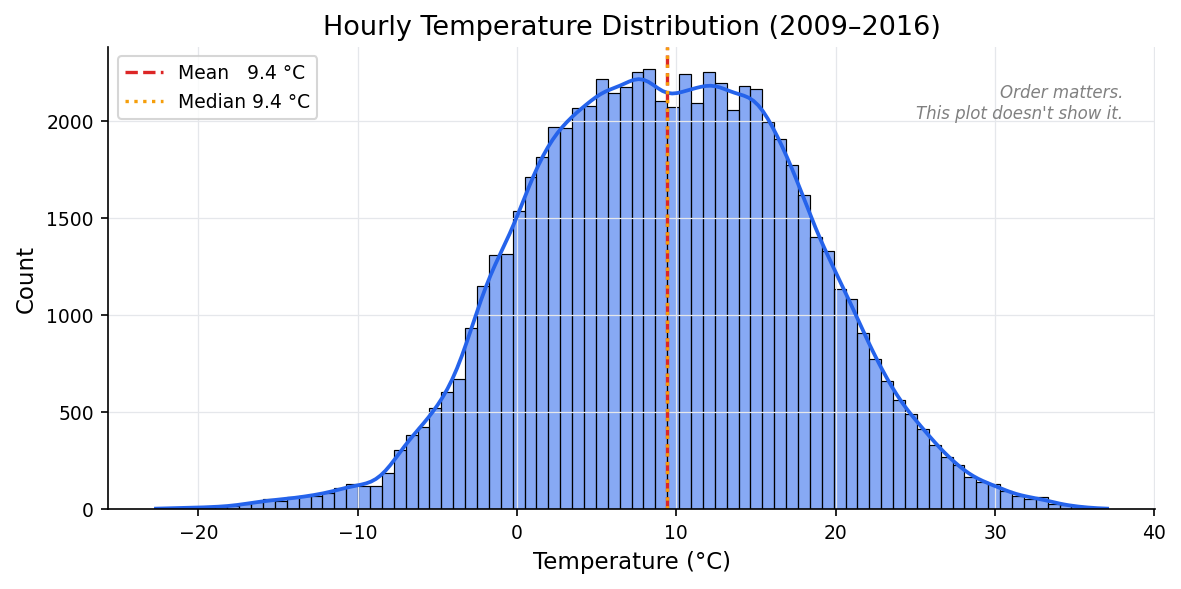

In [20]:
temp_vals = df[TARGET].dropna()
mean_t    = temp_vals.mean()
median_t  = temp_vals.median()

fig, ax = plt.subplots(figsize=(9, 4))

# Histogram + KDE overlay: 80 bins gives good resolution without noise
sns.histplot(
    temp_vals, bins=80, kde=True, color=BLUE,
    alpha=0.55, ax=ax, line_kws={"linewidth": 1.8}
)

# Mean and median lines — they are close because the distribution is near-symmetric,
# but the bimodal shape (driven by winter/summer) is the key thing to notice.
ax.axvline(mean_t,   color=RED,    linewidth=1.6, linestyle="--", label=f"Mean   {mean_t:.1f} °C")
ax.axvline(median_t, color=ORANGE, linewidth=1.6, linestyle=":",  label=f"Median {median_t:.1f} °C")

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Count")
ax.set_title("Hourly Temperature Distribution (2009–2016)")
ax.legend(fontsize=9)

# The key point: a histogram collapses time — it looks well-behaved,
# but it hides the ordering structure that makes this data non-IID.
ax.text(
    0.97, 0.92,
    "Order matters.\nThis plot doesn't show it.",
    transform=ax.transAxes, ha="right", va="top",
    fontsize=8, color="gray", style="italic",
)

save_plot(fig, IMAGES_DIR / "distribution.png", close=False)
plt.show()

## 7. Stationarity Tests

### Hypothesis recap

| Test | H₀ (null) | H₁ (alternative) | Reject H₀ when |
|------|-----------|-------------------|----------------|
| **ADF** | Unit root exists (non-stationary) | No unit root (stationary) | p-value < α |
| **KPSS** | Series is stationary | Series is non-stationary | p-value < α |

They test **opposite** things. Both rejecting (or both failing to reject) tells us something; disagreement tells us even more.

In [21]:
def run_adf(series: pd.Series, name: str = "series") -> dict:
    # autolag='AIC' lets statsmodels pick the lag order that minimises AIC,
    # avoiding the need to guess a max-lag manually.
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "test": "ADF",
        "series": name,
        "statistic": round(result[0], 4),
        "p_value": round(result[1], 6),
        "lags_used": result[2],
        "n_obs": result[3],
        "critical_1pct": round(result[4]["1%"], 4),
        "critical_5pct": round(result[4]["5%"], 4),
        "reject_H0": result[1] < ALPHA,
        "interpretation": "Stationary" if result[1] < ALPHA else "Non-stationary",
    }


def run_kpss(series: pd.Series, name: str = "series") -> dict:
    # regression='c' tests level stationarity (constant mean, no trend).
    # Use regression='ct' if you want to test trend stationarity instead.
    # statsmodels only returns p-values in {0.01, 0.025, 0.05, 0.10} —
    # it's a lookup table, not a continuous value.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # suppress lags-truncation warning
        result = kpss(series.dropna(), regression="c", nlags="auto")
    return {
        "test": "KPSS",
        "series": name,
        "statistic": round(result[0], 4),
        "p_value": round(result[1], 4),
        "lags_used": result[2],
        "critical_5pct": round(result[3]["5%"], 4),
        "reject_H0": result[1] < ALPHA,
        "interpretation": "Non-stationary" if result[1] < ALPHA else "Stationary",
    }

In [22]:
# Run on the full series (all 8 years) so the test sees the slow warming trend
temp_full = df[TARGET].dropna()

adf_result  = run_adf(temp_full,  name="T (degC) — full series")
kpss_result = run_kpss(temp_full, name="T (degC) — full series")

results_df = pd.DataFrame([adf_result, kpss_result]).set_index("test")
display(results_df[["series", "statistic", "p_value", "reject_H0", "interpretation","critical_1pct","critical_5pct"]])

,series,statistic,p_value,reject_H0,interpretation,critical_1pct,critical_5pct
test,,,,,,,
ADF,T (degC) — full series,-8.5081,0.00,True,Stationary,-3.4304,-2.8616
KPSS,T (degC) — full series,0.9069,0.01,True,Non-stationary,NaN,0.4630


In [23]:
# Translate the two p-values into a plain-language verdict
adf_stationary  = adf_result["reject_H0"]       # True = ADF says stationary
kpss_stationary = not kpss_result["reject_H0"]  # True = KPSS says stationary

if adf_stationary and kpss_stationary:
    verdict = "Both tests agree: the series is STATIONARY."
elif not adf_stationary and not kpss_stationary:
    verdict = "Both tests agree: the series is NON-STATIONARY."
elif adf_stationary and not kpss_stationary:
    # Classic disagreement pattern for trend-stationary series:
    # ADF rejects the unit-root null (so no random walk), but KPSS rejects
    # stationarity too (because of the slow drift). Differencing or
    # detrending will resolve this before modeling.
    verdict = (
        "Tests disagree: ADF says stationary, KPSS says non-stationary. "
        "Likely trend-stationary — fluctuates around a slow drift. "
        "Differencing or detrending will help."
    )
else:
    verdict = (
        "Tests disagree: ADF says non-stationary, KPSS says stationary. "
        "Possible unit-root process. Further analysis needed."
    )

print("=" * 62)
print("VERDICT")
print("=" * 62)
print(verdict)
print()
print(f"  ADF  p={adf_result['p_value']:.6f}  → "
      f"{'Reject H₀ (stationary)' if adf_stationary else 'Fail to reject H₀ (non-stationary)'}")
print(f"  KPSS p={kpss_result['p_value']:.4f}    → "
      f"{'Fail to reject H₀ (stationary)' if kpss_stationary else 'Reject H₀ (non-stationary)'}")

VERDICT
Tests disagree: ADF says stationary, KPSS says non-stationary. Likely trend-stationary — fluctuates around a slow drift. Differencing or detrending will help.

  ADF  p=0.000000  → Reject H₀ (stationary)
  KPSS p=0.0100    → Reject H₀ (non-stationary)


## 8. ACF Preview (Full Analysis in Weekend 2)

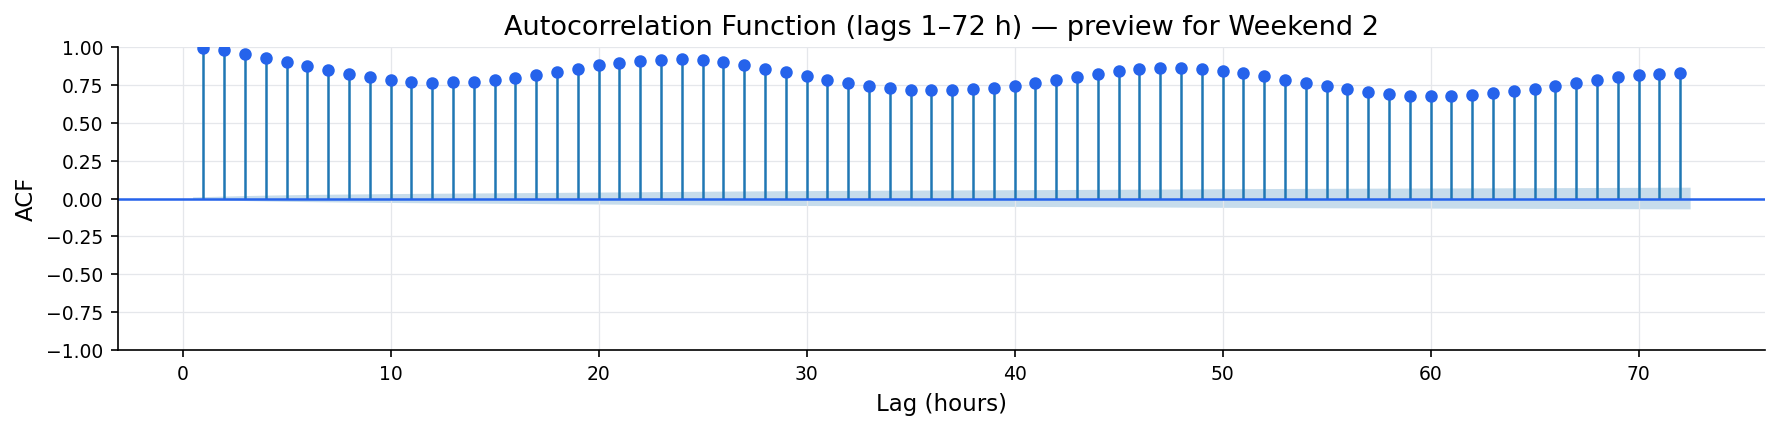

Weekend 2 question: what's the simplest possible way to use this structure to forecast?


In [24]:
fig, ax = plt.subplots(figsize=(12, 3))

# Show 72 lags = 3 days. The ACF typically stays high for many hours
# because temperature autocorrelation decays slowly — yesterday is
# strongly predictive of today. Weekend 2 exploits this directly.
plot_acf(temp_full, lags=72, ax=ax, alpha=0.05, color=BLUE, zero=False)

ax.set_title("Autocorrelation Function (lags 1–72 h) — preview for Weekend 2")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("ACF")
plt.tight_layout()
plt.show()

print("Weekend 2 question: what's the simplest possible way to use this structure to forecast?")

## 9. Summary

| Finding | Detail |
|---------|--------|
| **Yearly seasonality** | Strong — ~18 °C peak-to-trough swing |
| **Daily seasonality** | Strong — ~8–12 °C diurnal cycle |
| **Trend** | Slow upward drift (~0.5 °C over 6 training years) |
| **Distribution** | Near-symmetric; bimodal hint from winter/summer peaks |
| **ADF result** | See Section 7 output |
| **KPSS result** | See Section 7 output |
| **Verdict** | Trend-stationary — seasonal + slow drift; not strictly stationary |

**What comes next:**  
We have described the data exhaustively. Weekend 2 asks: *what's the simplest possible forecasting model — and how well does it actually work?*